In [ ]:
#import libraries and data     
import warnings 
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import chi2 ,RFECV ,SelectKBest ,RFE
from collections import Counter
from sklearn.model_selection import cross_val_score ,train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
df_processed = pd.read_csv('../data/heart_processed.csv')
X = df_processed.drop('target', axis=1)
y = df_processed['target']

Selected features by XGBoost (above average): ['thal', 'cp', 'ca', 'exang']


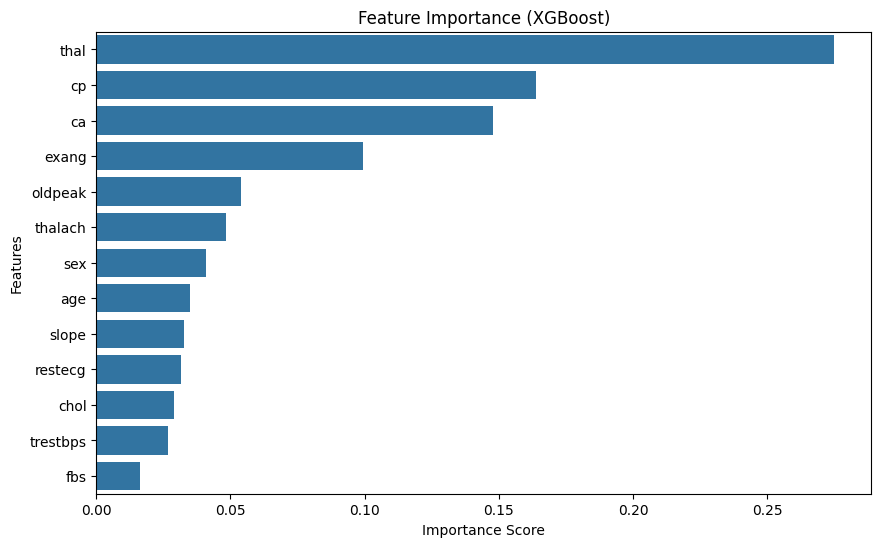

In [29]:
# XGBoost Feature Importance
xgb = XGBClassifier(random_state=42)
xgb.fit(X, y)
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

avg_importance = xgb_importances.mean()
xgb_selected_features = xgb_importances[xgb_importances > avg_importance].index

print("Selected features by XGBoost (above average):", list(xgb_selected_features))
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_importances, y=xgb_importances.index)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

best number for (k): 10
highest accuarcy: 0.835
selected feature: ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca']


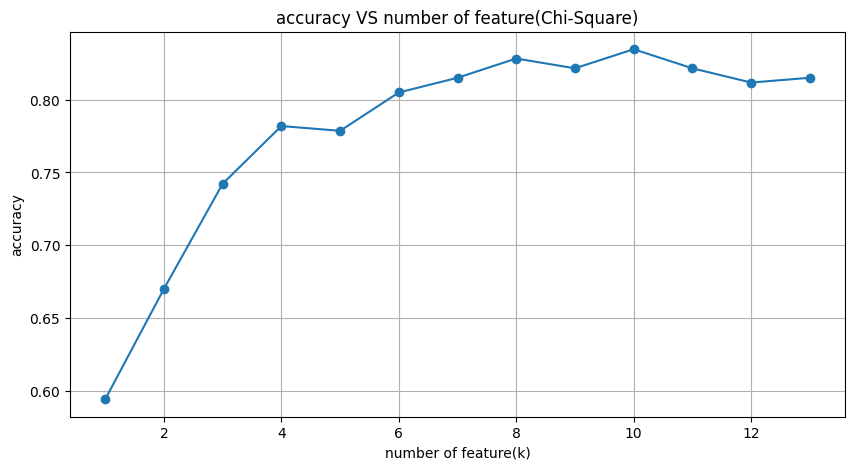

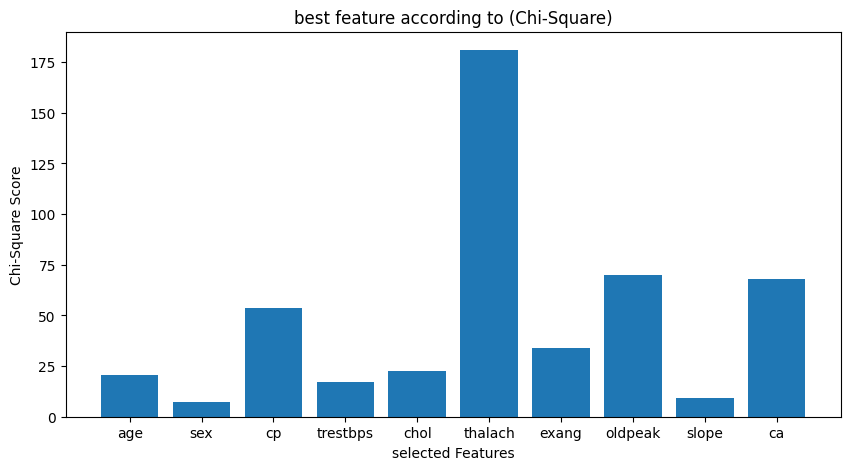

In [30]:
# chi square with Random Forest Classifier
best_score = 0
best_k = 1
best_features = None

scores_list = []
for k in range(1, X.shape[1] + 1):
    selector = SelectKBest(score_func=chi2, k=k)
    X_new = selector.fit_transform(X, y)
    score = cross_val_score(RandomForestClassifier(random_state=42), X_new, y, cv=5).mean()
    scores_list.append(score)
    if score > best_score:
        best_score = score
        best_k = k
        best_features = X.columns[selector.get_support()]

print(f"best number for (k): {best_k}")
print(f"highest accuarcy: {best_score:.3f}")
print("selected feature:", list(best_features))

plt.figure(figsize=(10,5))
plt.plot(range(1, X.shape[1] + 1), scores_list, marker='o')
plt.xlabel("number of feature(k)")
plt.ylabel("accuracy")
plt.title("accuracy VS number of feature(Chi-Square)")
plt.grid(True)
plt.show()

selector = SelectKBest(score_func=chi2, k=best_k)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
selected_scores = selector.scores_[selector.get_support()]

plt.figure(figsize=(10,5))
plt.bar(selected_features, selected_scores)
plt.xlabel("selected Features")
plt.ylabel("Chi-Square Score")
plt.title("best feature according to (Chi-Square)")
plt.show()

Optimal number of features: 12
Selected features: ['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
     Feature  Ranking  Selected
0        age        1      True
1        sex        1      True
2         cp        1      True
3   trestbps        1      True
5        fbs        1      True
6    restecg        1      True
7    thalach        1      True
8      exang        1      True
12      thal        1      True
9    oldpeak        1      True
10     slope        1      True
11        ca        1      True
4       chol        2     False


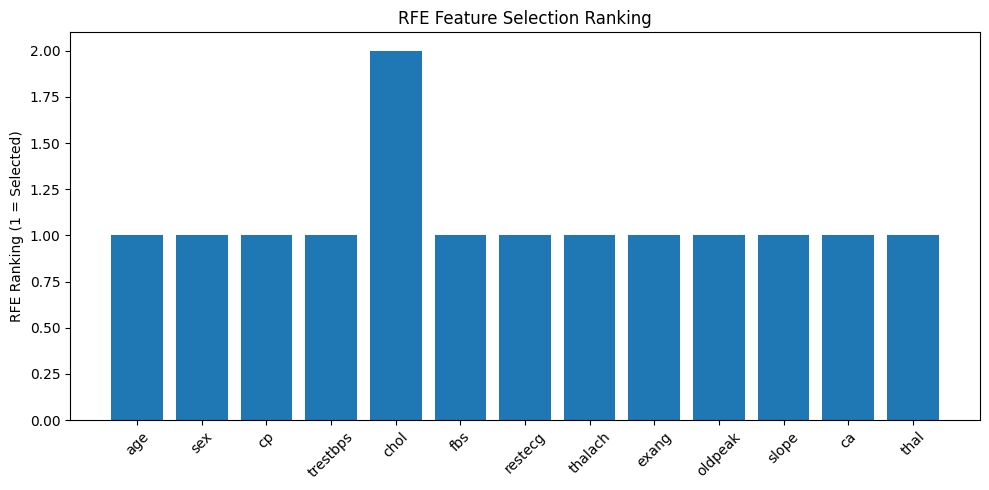

In [31]:
# RFE with Logistic Regression


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])


rfecv = RFECV(
    estimator=pipeline,
    step=1,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    importance_getter='named_steps.model.coef_'
)

rfecv.fit(X_train, y_train)


print("Optimal number of features:", rfecv.n_features_)

selected_features = X.columns[rfecv.support_]
print("Selected features:", list(selected_features))


rfecv_features = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfecv.ranking_,
    "Selected": rfecv.support_
})

print(rfecv_features.sort_values(by="Ranking"))


plt.figure(figsize=(10,5))
plt.bar(rfecv_features['Feature'], rfecv_features['Ranking'])
plt.xticks(rotation=45)
plt.ylabel("RFE Ranking (1 = Selected)")
plt.title("RFE Feature Selection Ranking")
plt.tight_layout()
plt.show()


y_pred = rfecv.predict(X_test)


In [34]:
# Combine Results and evaluation based on logical funcion
final_features = (set(xgb_selected_features) | (set(best_features) & set(X.columns[rfecv.support_])))
print("Final selected features:", list(final_features))

model=SVC(random_state=42)
model.fit(X[list(final_features)], y)
scores = cross_val_score(model, X[list(final_features)], y, cv=5)  
print("Cross-validation scores:", np.round(scores, 3))
print("Mean accuracy:", scores.mean())


Final selected features: ['exang', 'trestbps', 'slope', 'age', 'thalach', 'thal', 'sex', 'oldpeak', 'cp', 'ca']
Cross-validation scores: [0.689 0.623 0.705 0.7   0.617]
Mean accuracy: 0.6666120218579235
